# Presentation figures (260616)

Dataset: `data/embeddings/proof_benchmarked_260505/var-ring-sym_phi-0.95_cpl-0.4/M10_T500_I6`.

Plots: MTS heatmap; MPI heatmaps for `cov_EmpiricalCovariance`, `spearmanr`, `mi_kraskov_NN-4`; unravel off-diagonals to 1D barcode; two-SPI scatter.

In [17]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import spearmanr, zscore
from sklearn.preprocessing import robust_scale

# ---- tweakable knobs ----
dpi = 500
save_fmt = "svg"  # "png" or "svg"
use_latex = True

DATASET = Path("../../data/embeddings/proof_benchmarked90_260603/var-phi-0.95_cpl-0.4/M5_T500_I4")
# DATASET = Path("../../data/embeddings/proof_benchmarked90_260603/kuramoto_omega-fast/M5_T500_I1")
output_dir = Path("figures3")
output_dir.mkdir(parents=True, exist_ok=True)

# Presentation-tuned rcParams. Override individually below if needed.
sns.set_theme(
    style="white",
    rc={
        "text.usetex": use_latex,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 16,
        "axes.titlesize": 22,
        "axes.labelsize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
        "legend.title_fontsize": 16,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
        "savefig.transparent": True,
    },
)

# Load meta once (for directedness + labels per SPI)
with (DATASET / "meta.json").open() as f:
    META = json.load(f)
SPI_META = {e["name"]: e for e in META.get("pyspi", {}).get("spis", []) if e.get("name")}
ARCHIVE = DATASET / "spi_mpis.npz"
TAG = f"{DATASET.parent.name}_{DATASET.name}"
TAG

'var-phi-0.95_cpl-0.4_M5_T500_I4'

## MTS heatmap

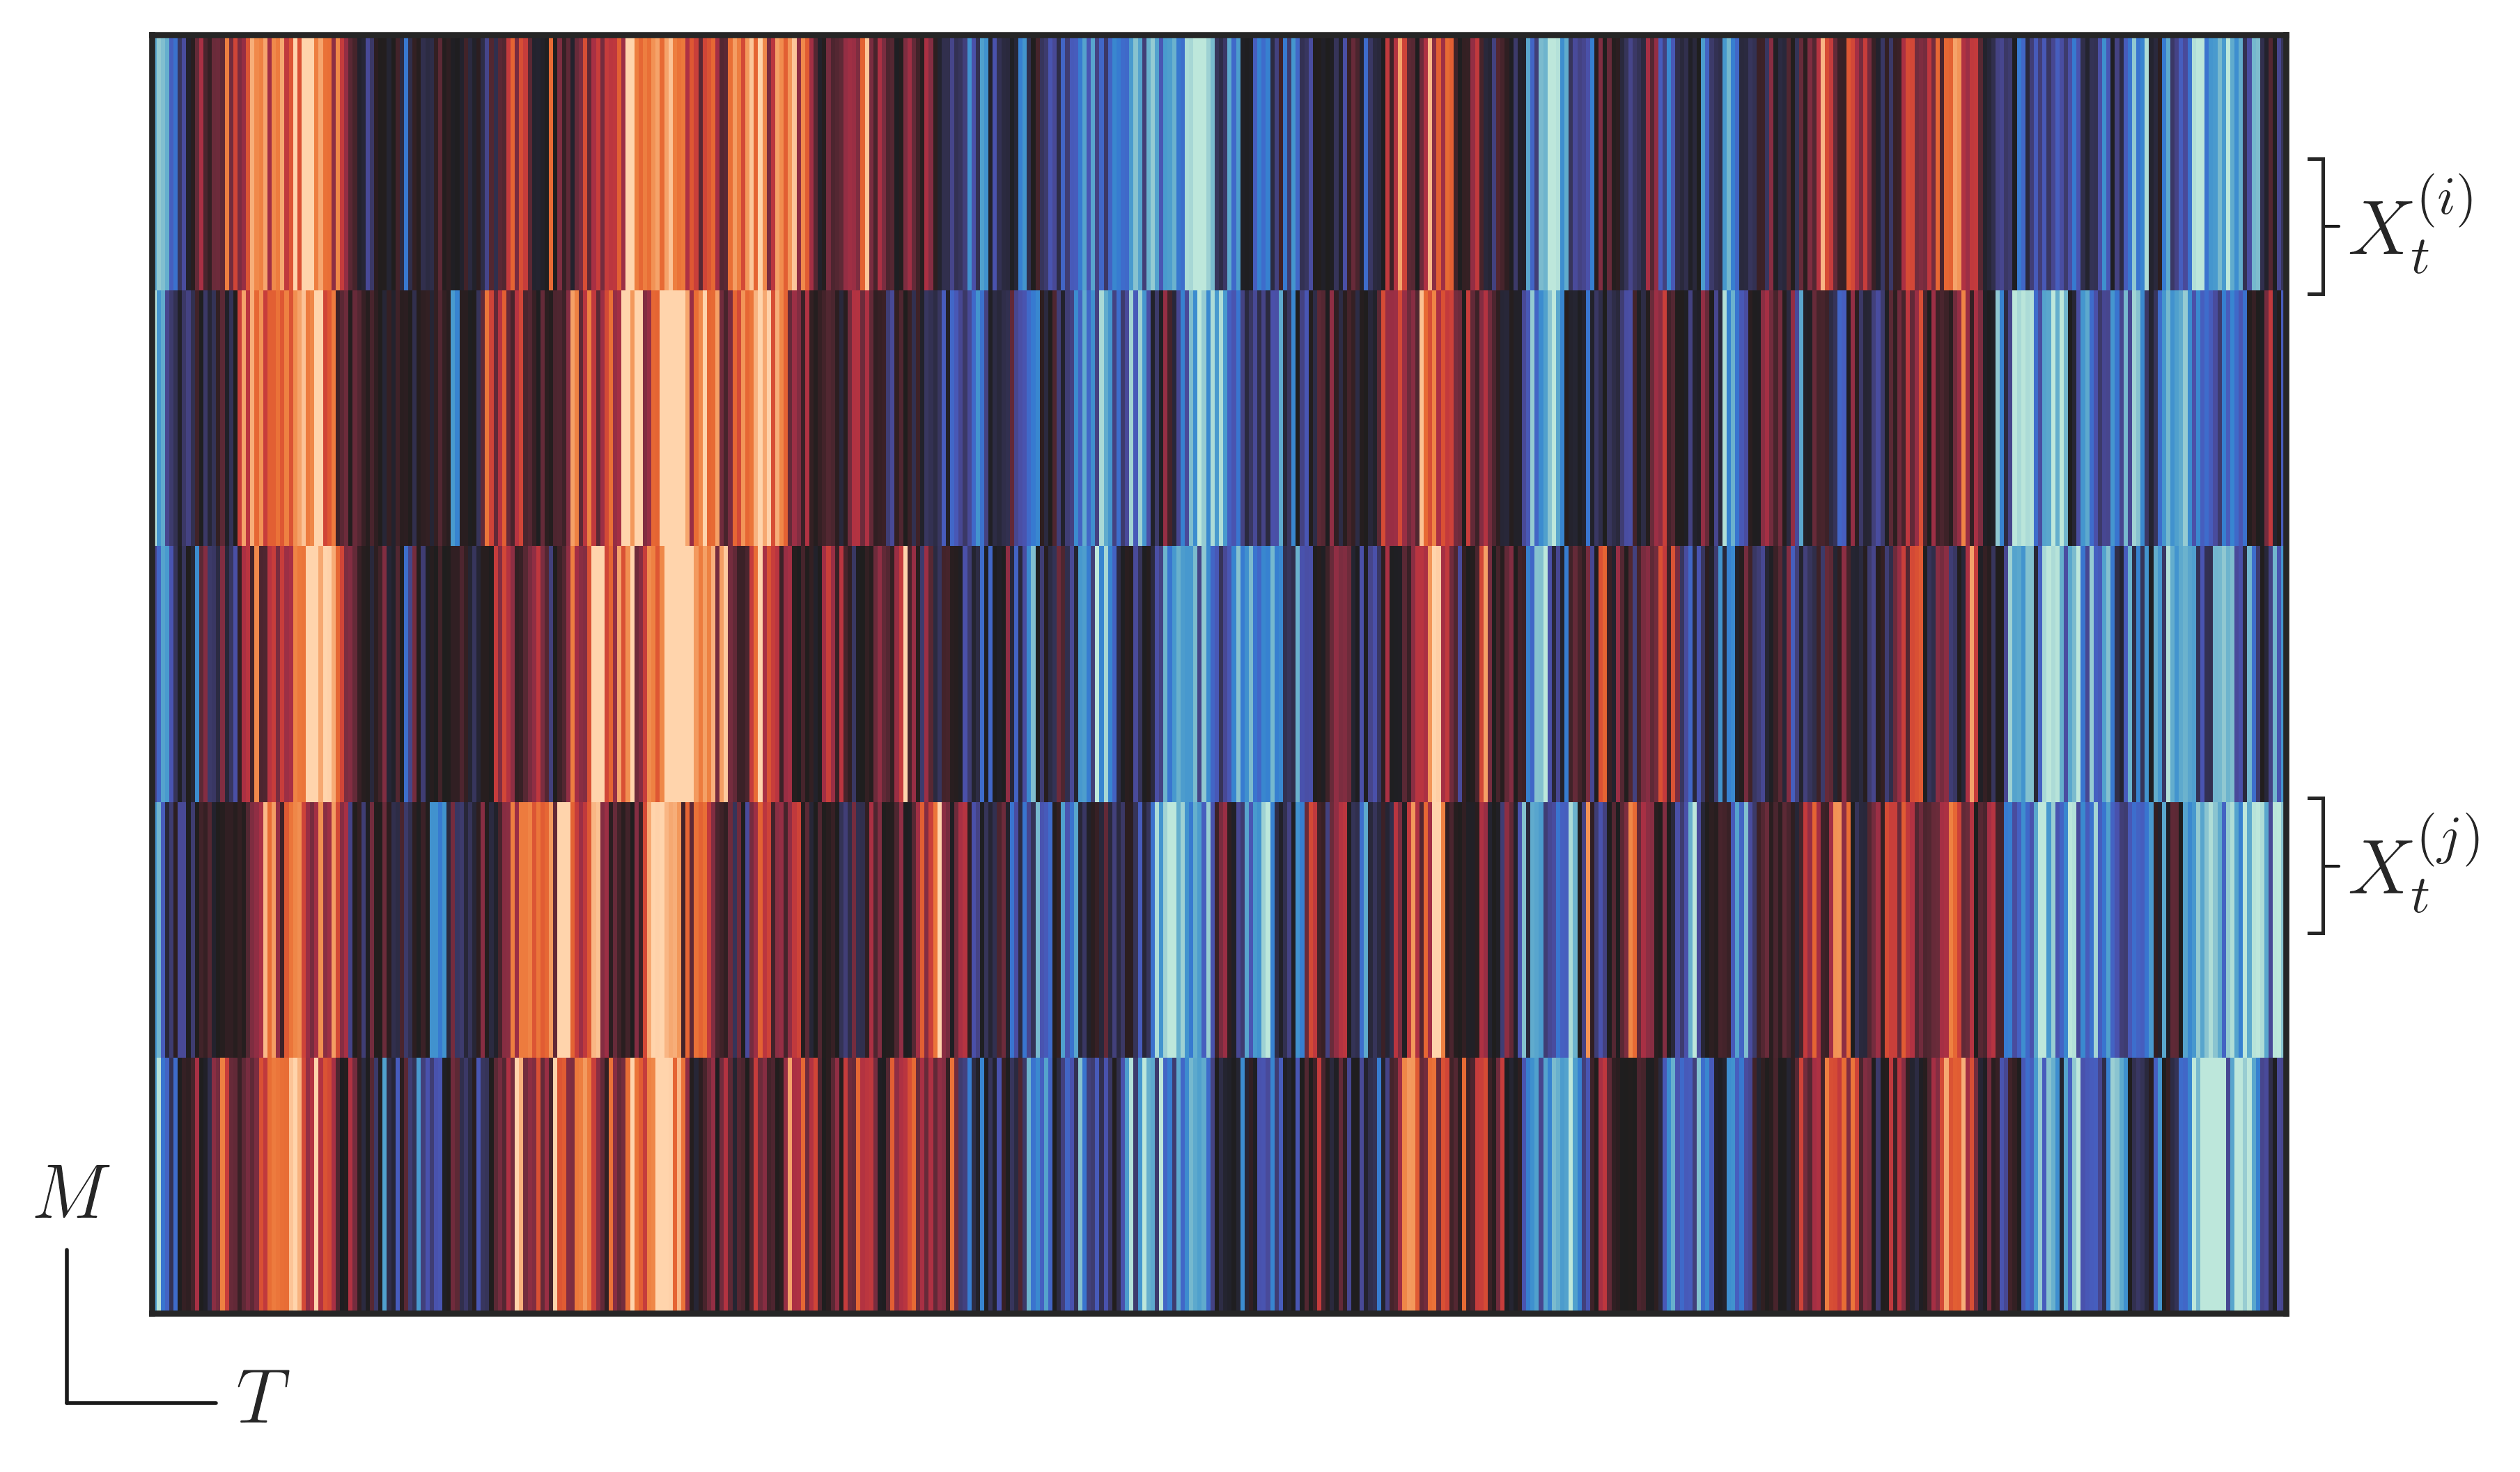

In [18]:
# ---- tweakable ----
mts_cmap = "icefire"
mts_vmin, mts_vmax = -2.0, 2.0
mts_figsize = (7, 4)

data = np.load(DATASET / "timeseries.npy").astype(float)
if data.shape[0] > data.shape[1]:  # ensure (M, T)
    data = data.T
scaled = zscore(data, axis=1, nan_policy="omit")
scaled = np.nan_to_num(scaled, nan=0.0, posinf=0.0, neginf=0.0)

fig, ax = plt.subplots(figsize=mts_figsize, dpi=dpi)
ax.pcolormesh(scaled, shading="flat", vmin=mts_vmin, vmax=mts_vmax,
              cmap=sns.color_palette(mts_cmap, as_cmap=True))
ax.set_xticks([]); ax.set_yticks([])

# axes-fraction coords: (0,0)=bottom-left. Move each freely.
# ax.text(-0.055, 0.00, r"$\uparrow$", transform=ax.transAxes, clip_on=False)
ax.text(-0.055, 0.075, r"$M$", transform=ax.transAxes, clip_on=False)
# ax.text(-0.03, -0.09, r"$\rightarrow$", transform=ax.transAxes, clip_on=False)
ax.text(0.04, -0.085, r"$T$", transform=ax.transAxes, clip_on=False)

ax.text(1.03, 0.828, r"$X_t^{(i)}$", transform=ax.transAxes, clip_on=False)  #8
ax.text(1.03, 0.328, r"$X_t^{(j)}$", transform=ax.transAxes, clip_on=False)  #3

ax.text(1.01, 0.335, r"$\Biggr]$", transform=ax.transAxes, clip_on=False)  #3
# ax.text(1.01, 0.335, r"$\Biggr\}$", transform=ax.transAxes, clip_on=False)  #3
ax.plot([1.018, 1.025], [0.35, 0.35], transform=ax.transAxes, clip_on=False, color="k", lw=0.6)

ax.text(1.01, 0.835, r"$\Biggr]$", transform=ax.transAxes, clip_on=False)  #8
ax.plot([1.018, 1.025], [0.85, 0.85], transform=ax.transAxes, clip_on=False, color="k", lw=0.6)

# lines: ax.plot([x0,x1],[y0,y1]). vertical then horizontal segment near corner.
ax.plot([-0.04, -0.04], [-0.07, 0.05], transform=ax.transAxes, clip_on=False, color="k", lw=0.8)
ax.plot([-0.04, 0.03], [-0.07, -0.07], transform=ax.transAxes, clip_on=False, color="k", lw=0.8)

fig.tight_layout(pad=0.05)
fig.savefig(output_dir / f"mts_heatmap_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight", pad_inches=0)
plt.show()

## Individual channel

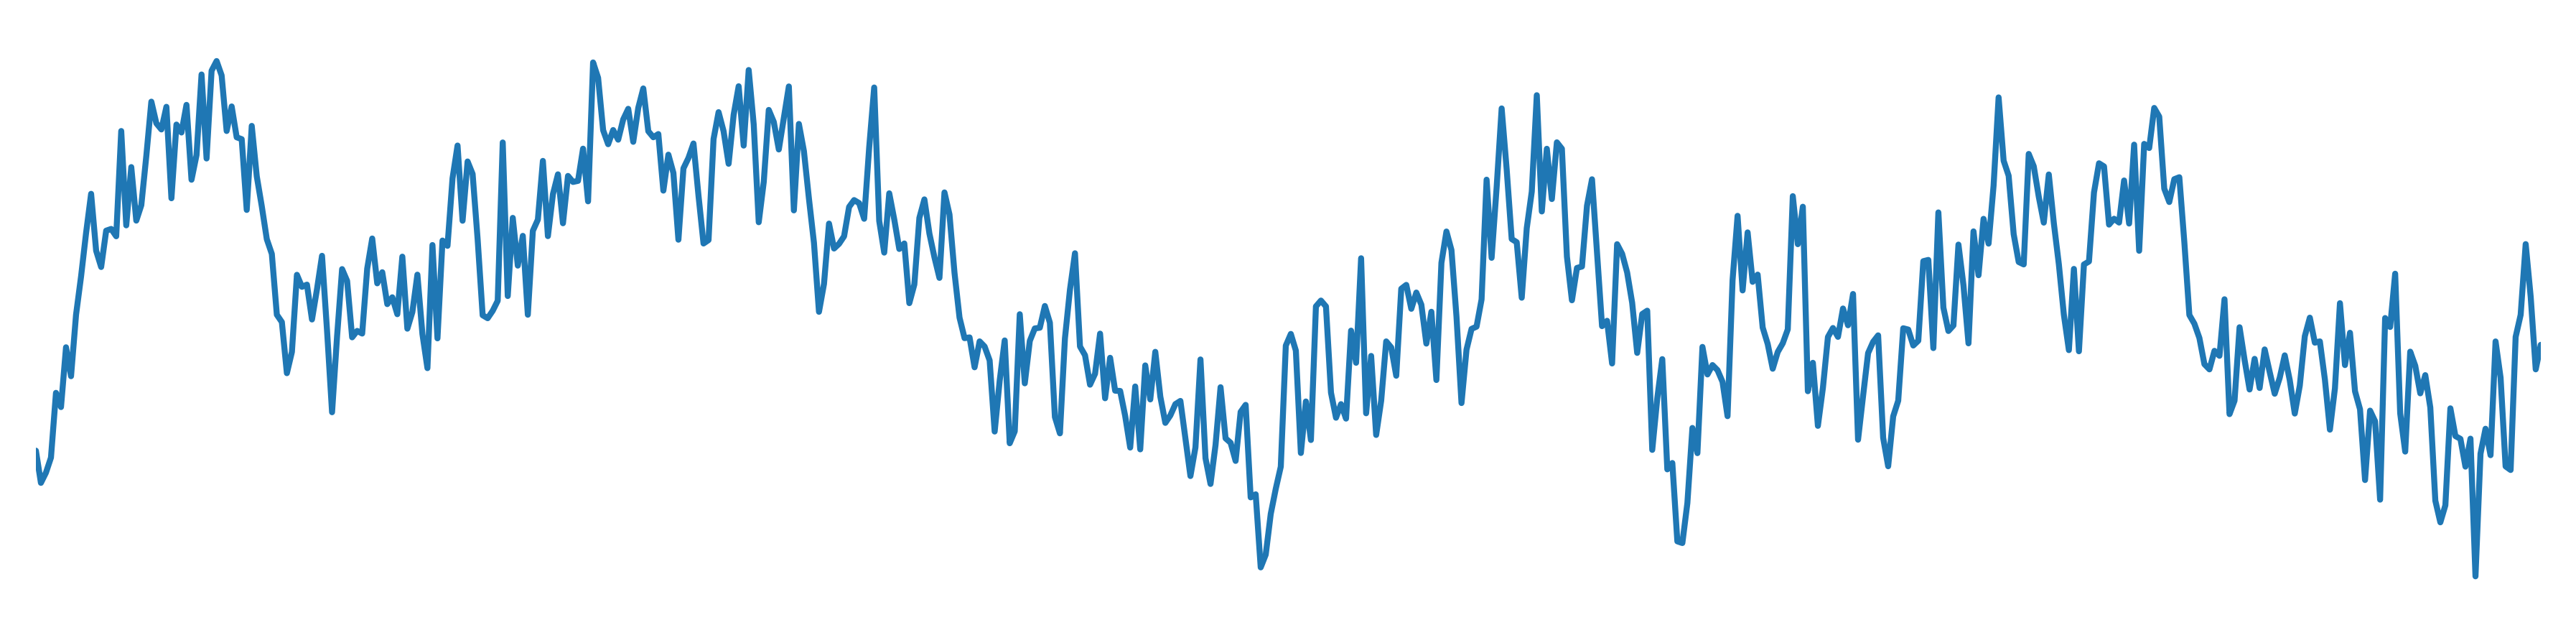

array([-1.46253014, -1.76129031, -1.66686344, -1.52730799, -0.92603981,
       -1.05805373, -0.50320607, -0.77179021, -0.20056173,  0.15482563,
        0.55864125,  0.92072242,  0.39306208,  0.24169677,  0.57888067,
        0.59495366,  0.52696764,  1.50354719,  0.62823886,  1.16881227,
        0.67219692,  0.81547785,  1.27320897,  1.77603733,  1.57477891,
        1.51812959,  1.72814429,  0.87956571,  1.5634377 ,  1.48974562,
        1.74622702,  1.05145407,  1.28023064,  2.02809   ,  1.24860358,
        2.06299519,  2.15280223,  2.01957655,  1.50377071,  1.73157561,
        1.4454081 ,  1.4279629 ,  0.77138847,  1.55107868,  1.08336103,
        0.80530983,  0.49999925,  0.36301693, -0.20102857, -0.26940745,
       -0.74353176, -0.54611236,  0.16925596,  0.05779202,  0.07811265,
       -0.24534355,  0.03628306,  0.34558451, -0.34804502, -1.10592818,
       -0.40084833,  0.22224851,  0.11277191, -0.41098455, -0.35121134,
       -0.37569571,  0.22622727,  0.50613564,  0.09024833,  0.19

In [19]:
def plot_channel(channel, *, clip=None, color="#1f77b4", figsize=(7, 1.6), linewidth=1.2):
    """Plot a single z-scored channel as a 1D time series line."""
    raw = np.load(DATASET / "timeseries.npy").astype(float)
    if raw.shape[0] > raw.shape[1]:
        raw = raw.T
    M, T = raw.shape
    if not 0 <= channel < M:
        raise IndexError(f"channel {channel} out of range for M={M}")
    series = zscore(raw, axis=1, nan_policy="omit")[channel]
    series = np.nan_to_num(series, nan=0.0, posinf=0.0, neginf=0.0)
    if clip is not None:
        series = series[clip[0]:clip[1]]
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.plot(np.arange(series.size), series, color=color, linewidth=linewidth)
    # ax.axhline(0.0, color="black", linewidth=0.5, alpha=0.5)
    ax.set_xlim(0, series.size - 1)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    fig.tight_layout(pad=0.05)
    clip_tag = f"_clip-{clip[0]}-{clip[1]}" if clip else ""
    fig.savefig(output_dir / f"channel-{channel}{clip_tag}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()
    return series

plot_channel(4)
# plot_channel(0, clip=(100, 300))

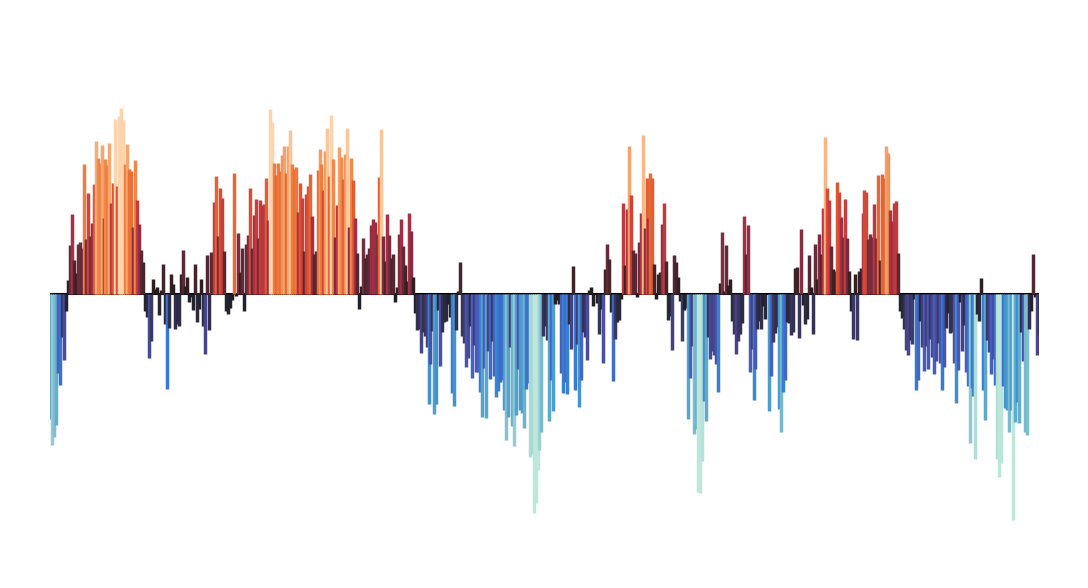

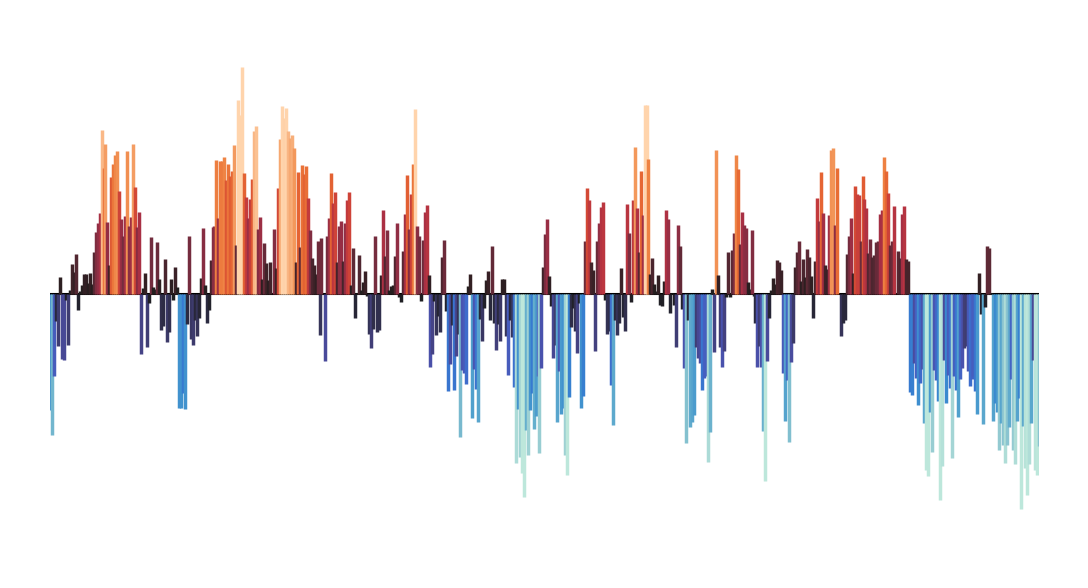

array([-1.31224727e+00, -1.58784961e+00, -9.20978362e-01, -3.07889845e-01,
       -5.91870840e-01,  1.84716465e-01, -7.37631972e-01, -7.49076421e-01,
       -6.92447768e-02, -5.79097922e-01,  4.43320076e-02,  3.31902744e-01,
        2.37680839e-01,  4.42351223e-01, -1.88796100e-01,  3.12426507e-02,
        9.65743759e-02,  2.17422875e-01,  2.15891676e-01,  1.16722854e-01,
        2.33255358e-01,  1.06890152e-01,  4.65225877e-01,  6.95543707e-01,
        7.96300352e-01,  9.08105433e-01,  1.83589697e+00,  1.41154265e+00,
        1.67926848e+00,  8.02657545e-01,  3.21517231e-01,  1.31085694e+00,
        1.45778799e+00,  1.55634308e+00,  1.60038900e+00,  1.15352118e+00,
        8.33398283e-01,  6.48549259e-01,  8.76805425e-01,  1.60718930e+00,
        7.62576998e-01,  8.63476932e-01,  1.68001377e+00,  1.19674623e+00,
        7.43325055e-01,  9.12001133e-01, -6.73782225e-01,  6.77734489e-02,
        2.34114396e-01, -6.00675340e-01, -1.03714418e-01,  6.39911533e-01,
        7.25993091e-02,  

In [20]:
def plot_channel_stem(channel, *, clip=None, cmap="icefire", vmin=-2.0, vmax=2.0,
                      figsize=(2, 1), linewidth=0.5, markersize=0.0):
    """Stem plot of a z-scored channel; each stem + head is colored by its value
    under the MTS-heatmap colormap (icefire, same vmin/vmax). Baseline y=0 centered."""
    raw = np.load(DATASET / "timeseries.npy").astype(float)
    if raw.shape[0] > raw.shape[1]:
        raw = raw.T
    M, T = raw.shape
    if not 0 <= channel < M:
        raise IndexError(f"channel {channel} out of range for M={M}")
    series = zscore(raw, axis=1, nan_policy="omit")[channel]
    series = np.nan_to_num(series, nan=0.0, posinf=0.0, neginf=0.0)
    if clip is not None:
        series = series[clip[0]:clip[1]]
    x = np.arange(series.size)
    cm = sns.color_palette(cmap, as_cmap=True)
    colors = cm(plt.Normalize(vmin, vmax)(series))  # per-sample color = heatmap color

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.axhline(0.0, color="black", linewidth=0.3, zorder=1)
    ax.vlines(x, 0.0, series, colors=colors, linewidth=linewidth, zorder=2)
    ax.scatter(x, series, s=markersize, c=colors, edgecolors="none",
               linewidths=0.5, zorder=3)
    m = max(np.abs(series).max() * 1.08, 1e-9)
    ax.set_xlim(0, series.size - 1)
    ax.set_ylim(-m, m)  # symmetric -> horizontal axis centered
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    # ax.spines["bottom"].set_position(("data", 0.0))  # move horizontal axis to y=0
    fig.tight_layout(pad=0.05)
    clip_tag = f"_clip-{clip[0]}-{clip[1]}" if clip else ""
    fig.savefig(output_dir / f"channel-stem-{channel}{clip_tag}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()
    return series

plot_channel_stem(4)
plot_channel_stem(1)
# plot_channel_stem(3, clip=(0,120))
# plot_channel_stem(8, clip=(0,120))

## MPI heatmaps for `cov_EmpiricalCovariance`, `spearmanr`, `mi_kraskov_NN-4`

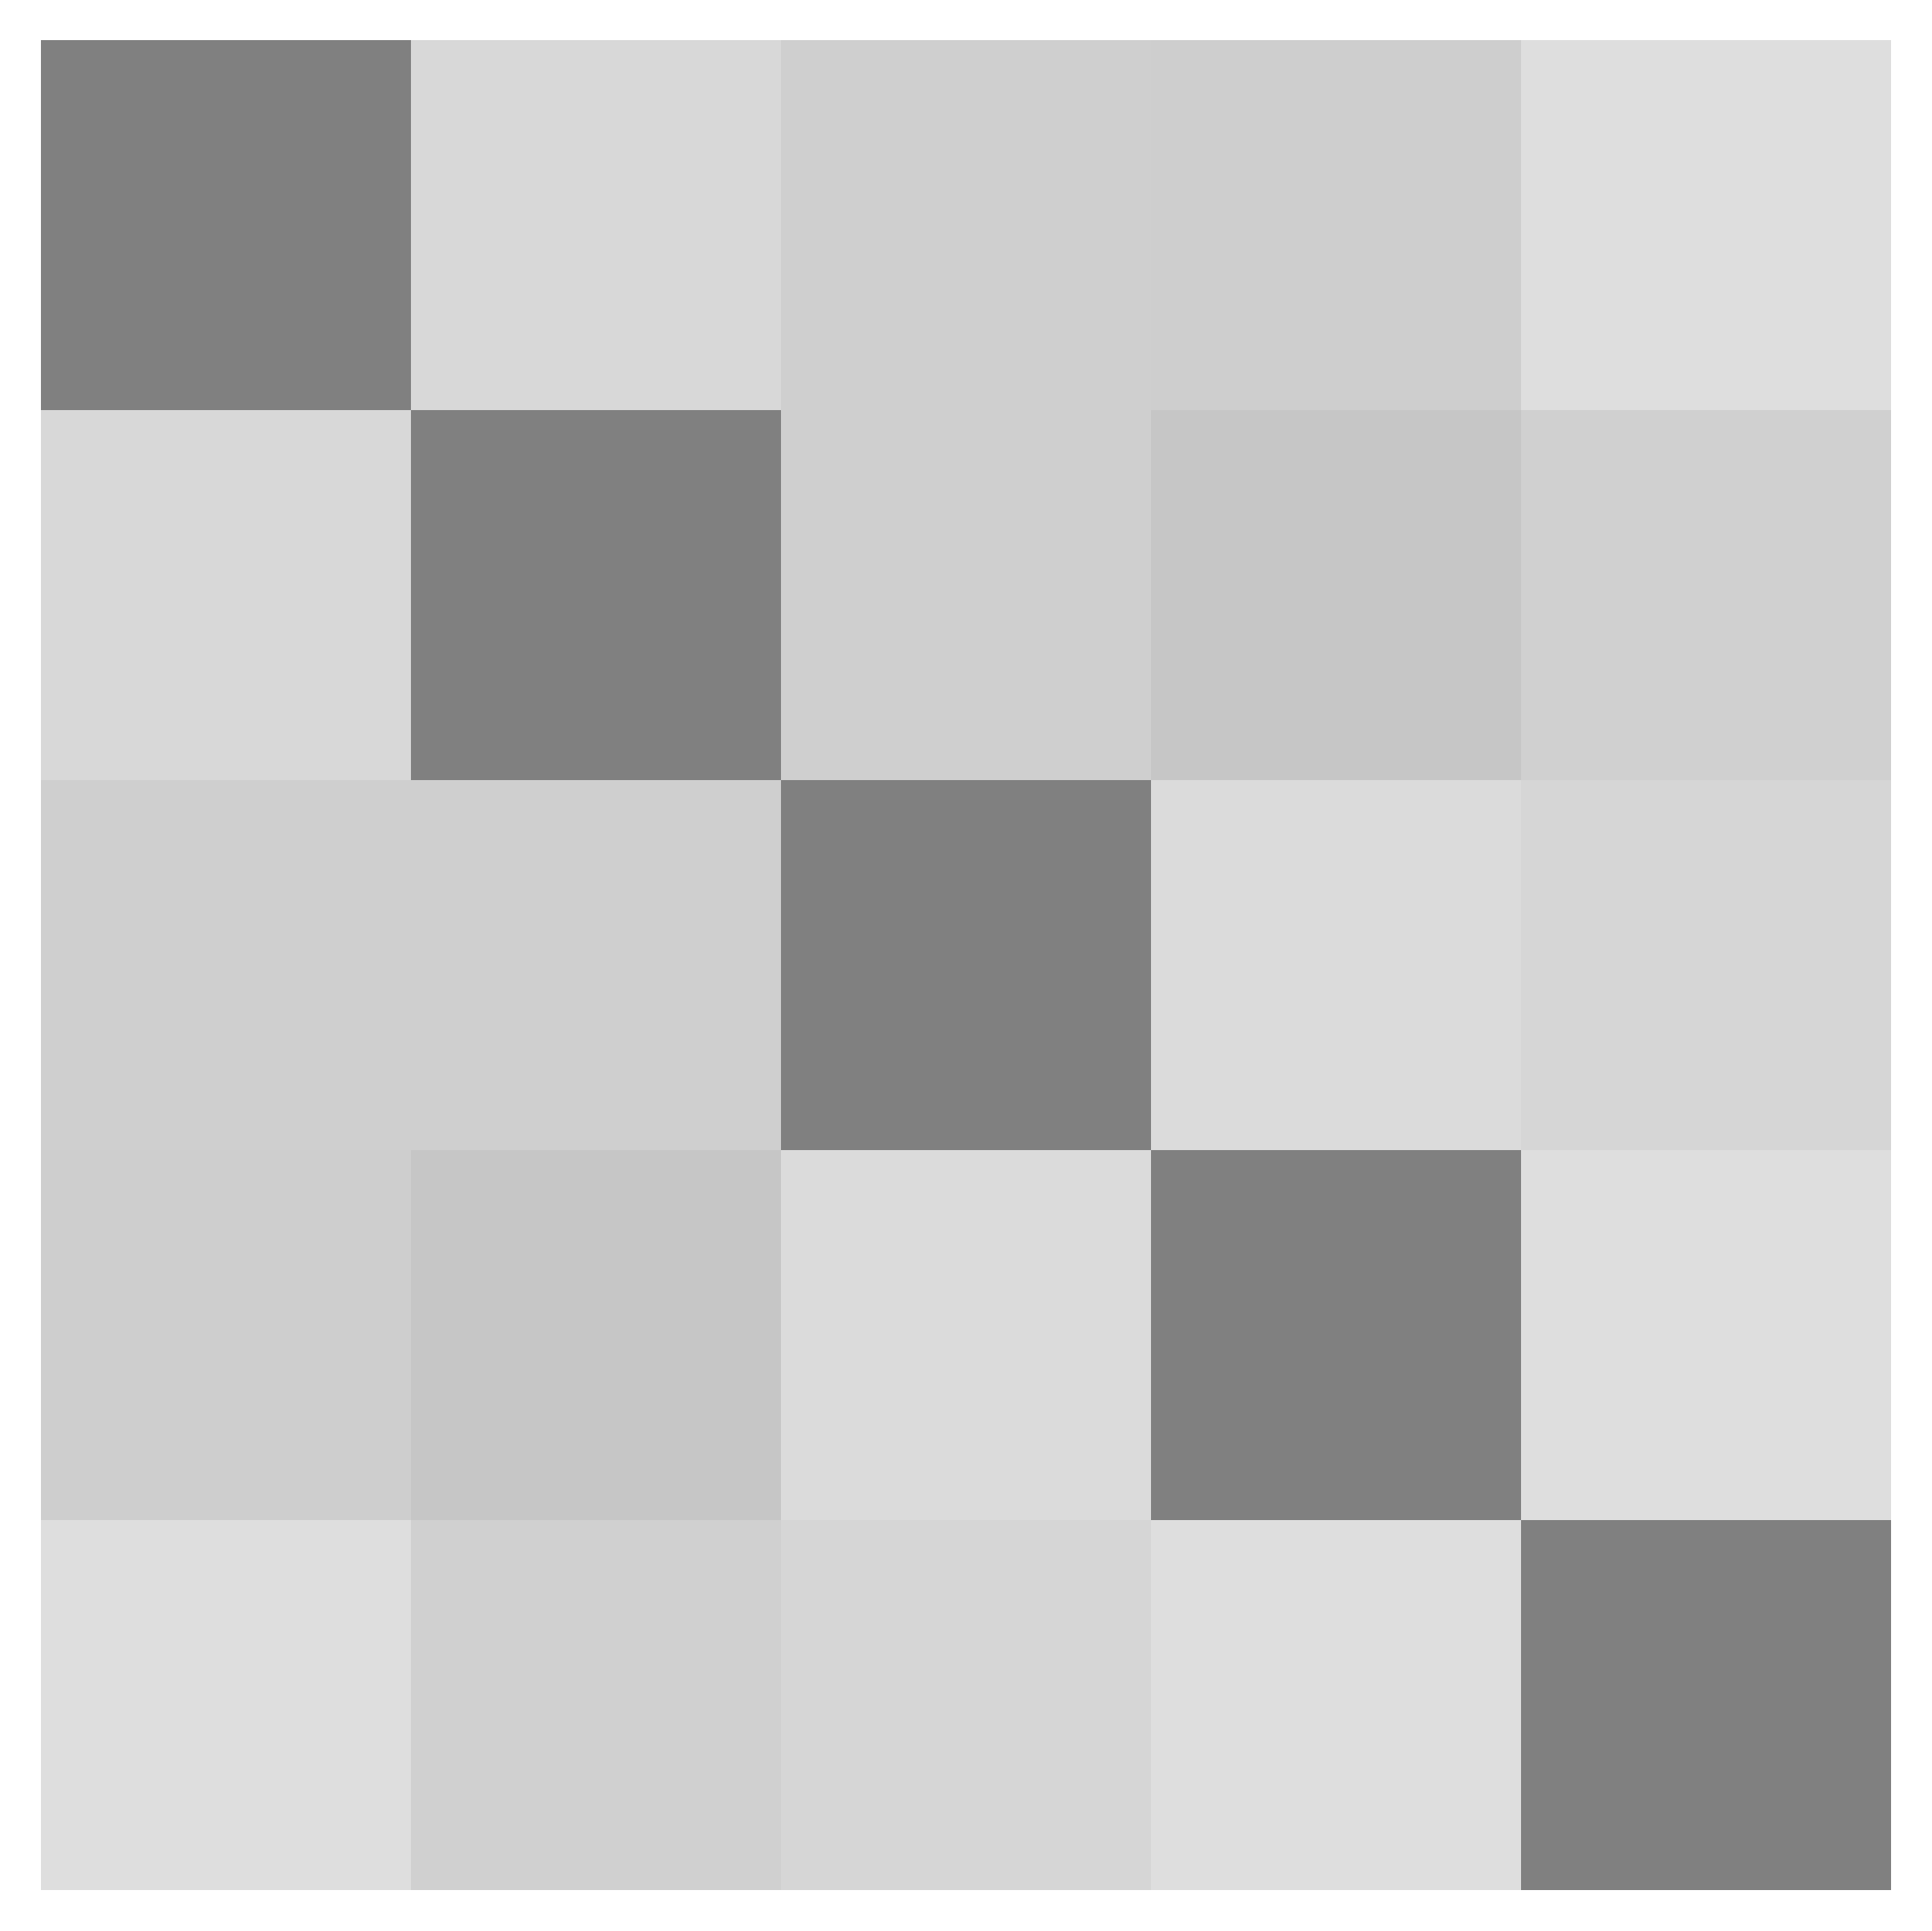

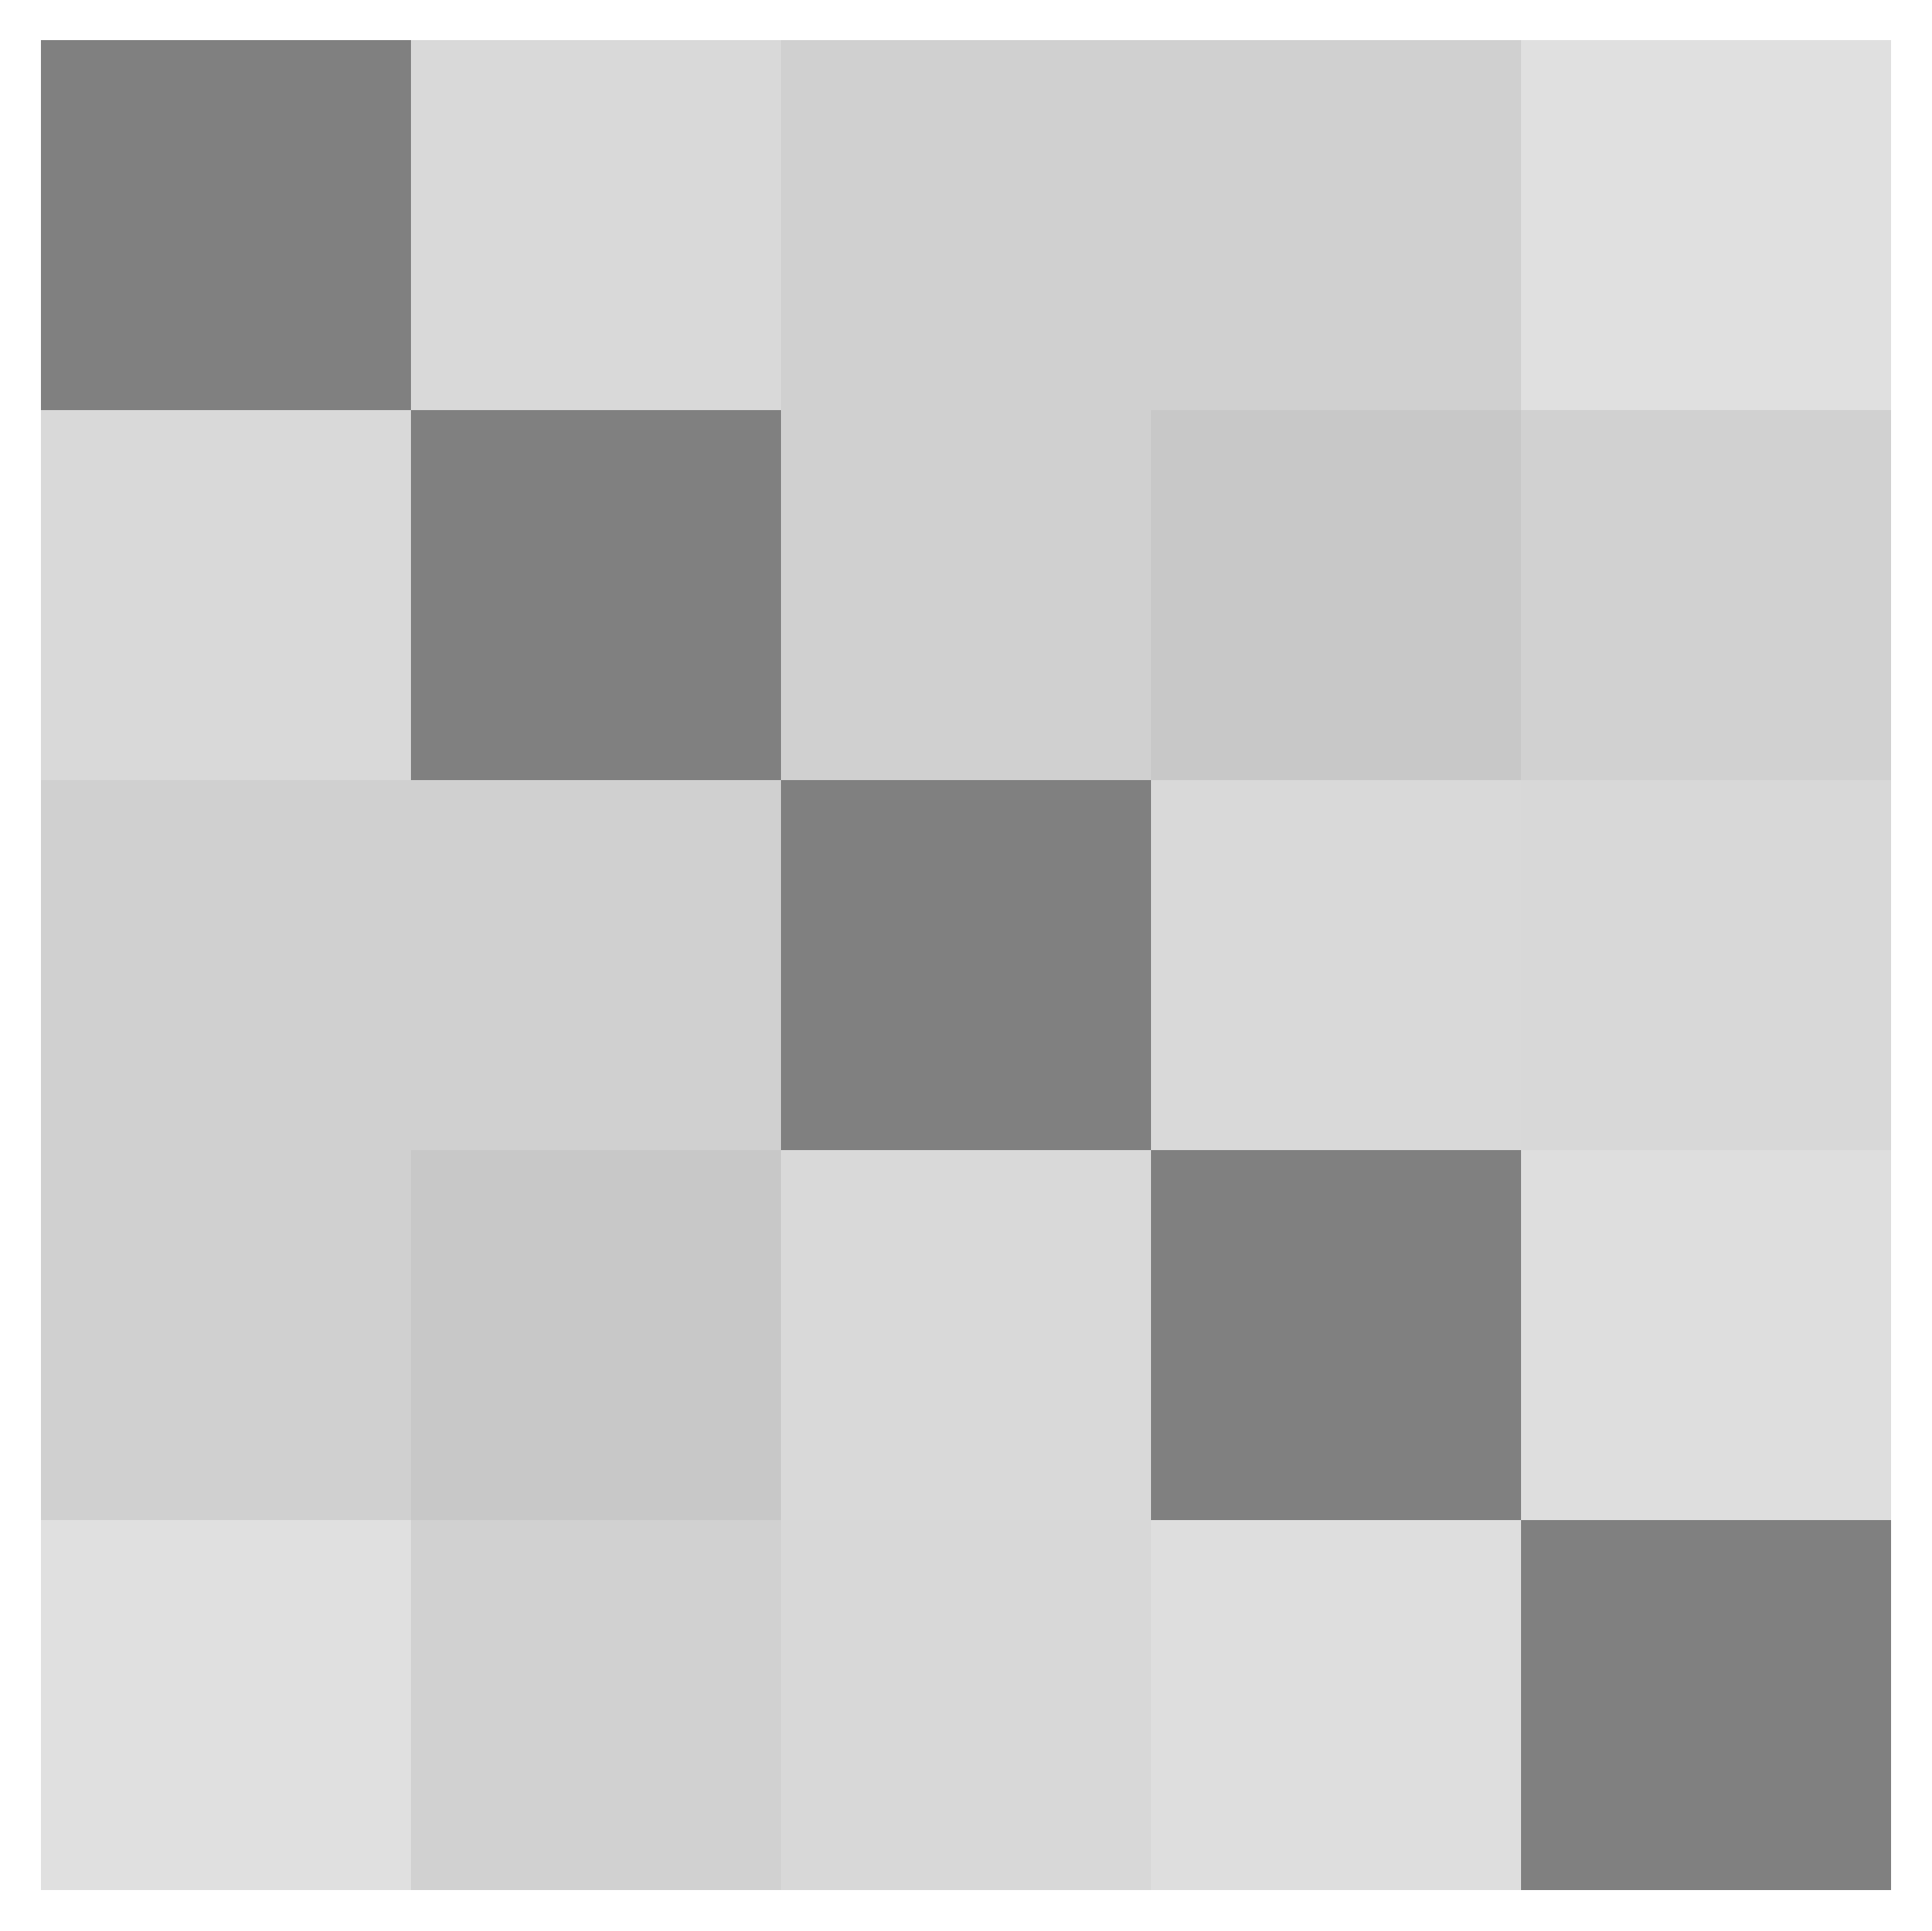

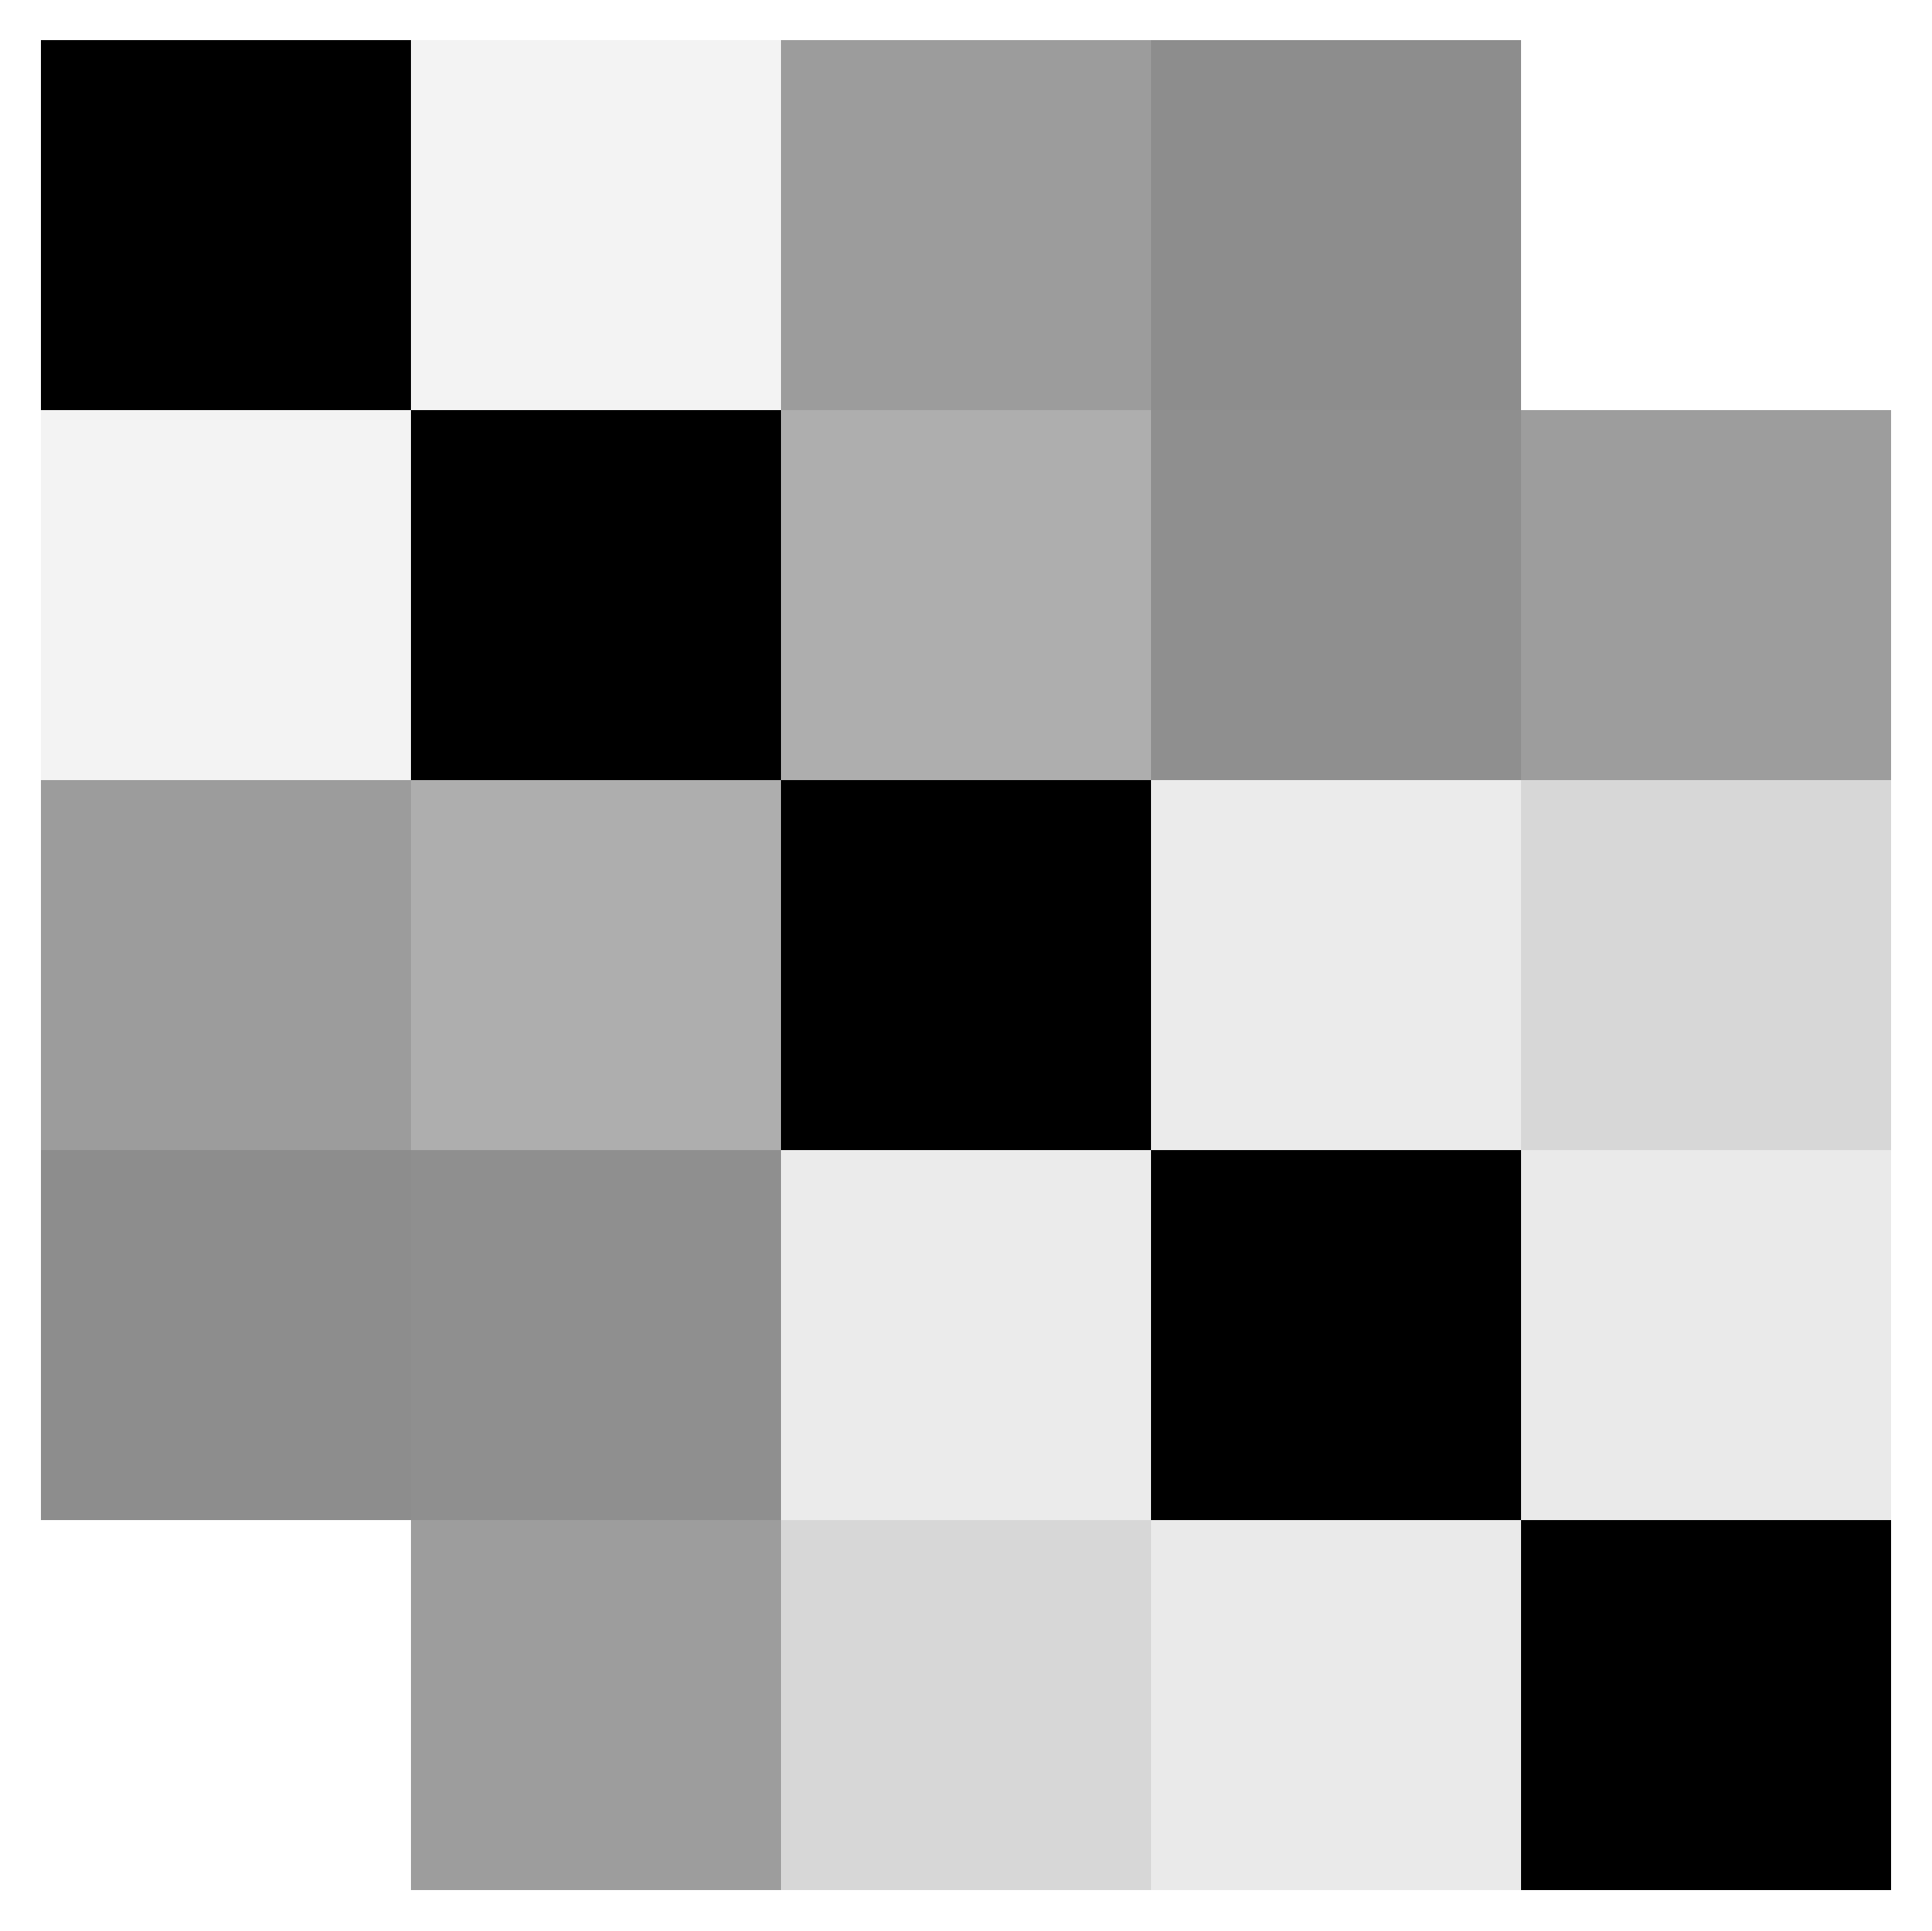

In [21]:
# ---- tweakable: per-SPI cmap and color bounds. None -> auto from data. ----
SPIS_MPI = {
    # name:                  (cmap,                                    vmin,  vmax,  center)
    "cov_EmpiricalCovariance": ("gray",                                  -1.0,  1.0,   0.0),
    "spearmanr":               ("gray",           -1.0,  1.0,   0.0),
    # "mi_kraskov_NN-4":         (sns.color_palette("mako", as_cmap=True), None,  None,  None),
    "mi_kraskov_NN-4":         ("gray"             , None,  None,  None),
}
mask_diagonal = False  # diagonal is self-coupling (max); exclude to avoid cmap bias
show_title = False   # toggle SPI name above each heatmap

with np.load(ARCHIVE) as npz:
    spi_mats = {name: np.asarray(npz[name], float) for name in SPIS_MPI}

for name, (cmap, vmin, vmax, center) in SPIS_MPI.items():
    mat = spi_mats[name].copy()
    if mask_diagonal:
        np.fill_diagonal(mat, np.nan)  # NaN cells are transparent and skipped by auto vmin/vmax
    fig, ax = plt.subplots(figsize=(5, 5), dpi=dpi)
    sns.heatmap(
        mat,
        cmap=cmap,
        vmin=vmin, vmax=vmax, center=center,
        square=True,
        xticklabels=False, yticklabels=False,
        cbar=False,
        ax=ax,
    )
    ax.set_xlabel(None); ax.set_ylabel(None)
    if show_title:
        title = name.replace("_", r"\_") if use_latex else name
        fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(output_dir / f"mpi_heatmap_{name}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()

## Unravel off-diagonals into a 1D vector heatmap ("barcode")

Always symmetrises each matrix (mean of upper and lower) and takes the lower-triangular off-diagonals.

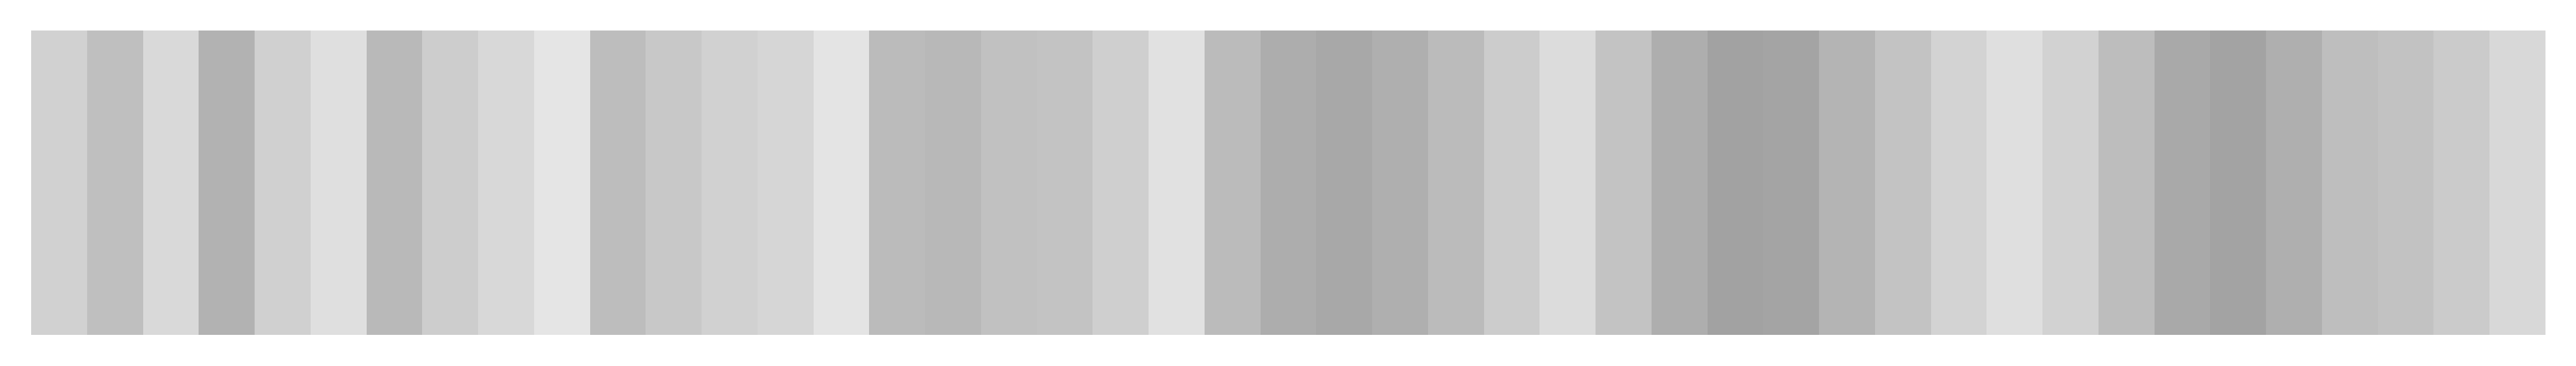

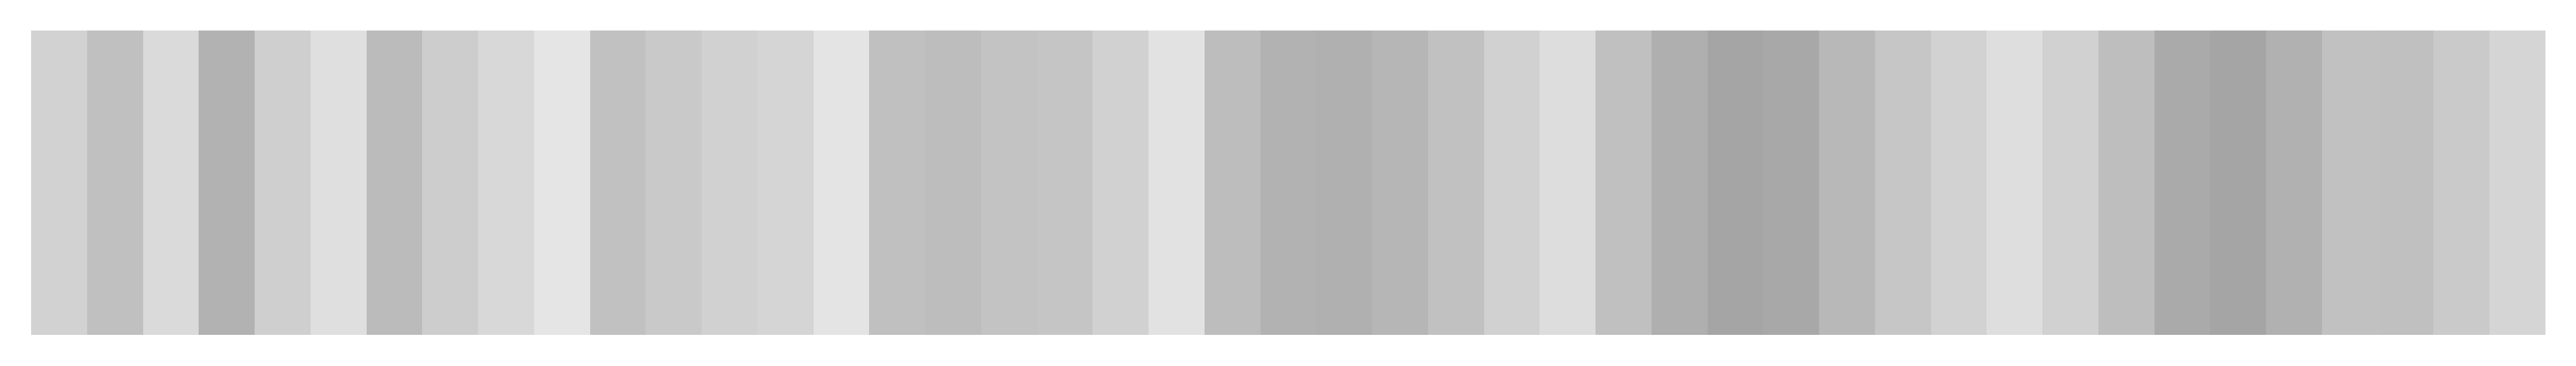

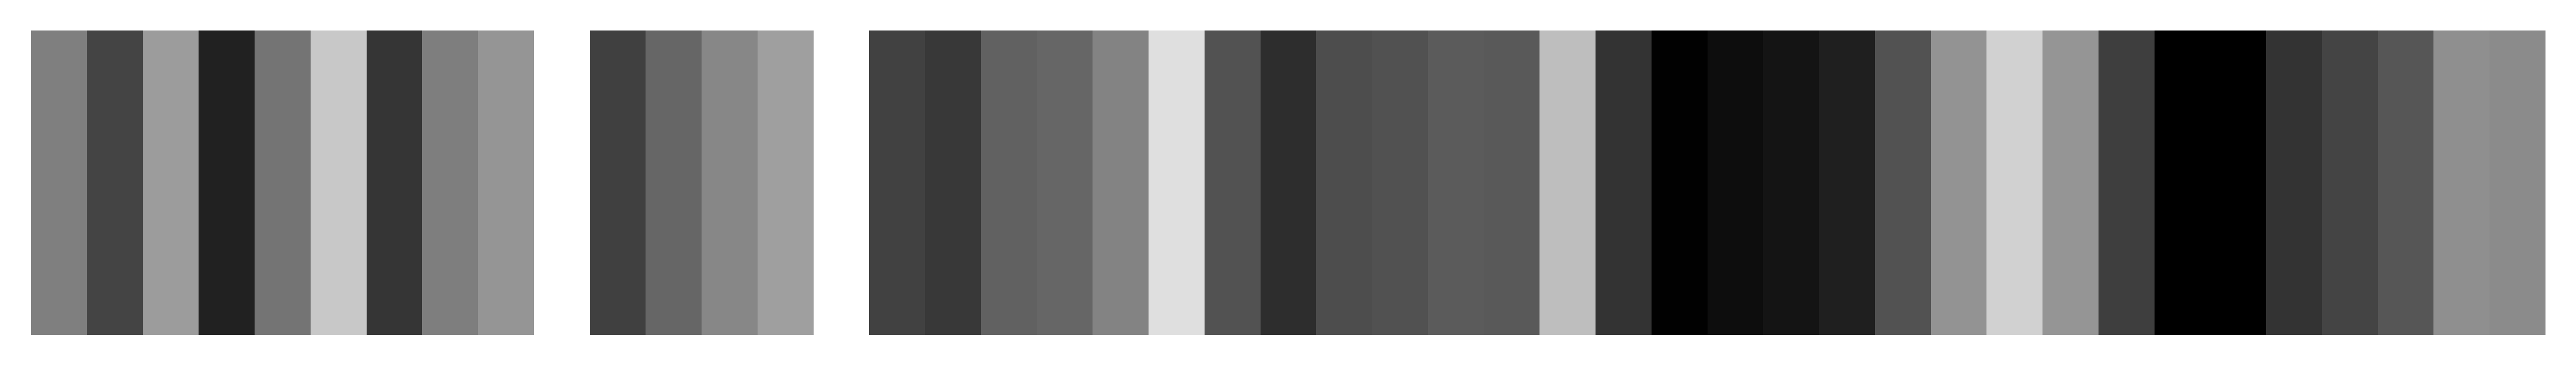

In [77]:
# ---- tweakable ----
barcode_width_per_entry = 0.18  # figure-width scaling per off-diag entry

def plot_barcode(vec, name, cmap, vmin, vmax, center):
    width = max(4.0, vec.size * barcode_width_per_entry)
    fig, ax = plt.subplots(figsize=(width, 1), dpi=dpi)
    sns.heatmap(
        vec[np.newaxis, :],
        cmap=cmap, vmin=vmin, vmax=vmax, center=center,
        cbar=False, xticklabels=False, yticklabels=False, ax=ax,
    )
    ax.set_xticks([]); ax.set_yticks([])
    ax.tick_params(left=False, bottom=False)
    fig.tight_layout(pad=0.05)
    fig.savefig(output_dir / f"barcode_{name}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()

for name, (cmap, vmin, vmax, center) in SPIS_MPI.items():
    mat = spi_mats[name]
    sym = 0.5 * (mat + mat.T)
    lower = np.tril(np.ones(sym.shape, bool), k=-1)
    plot_barcode(sym[lower], name, cmap, vmin, vmax, center)

## Two SPIs against each other (SPI-SPI space)

Symmetrises each matrix and uses the upper triangle. Set `spi_x` / `spi_y` to any pair from `spi_mpis.npz`.

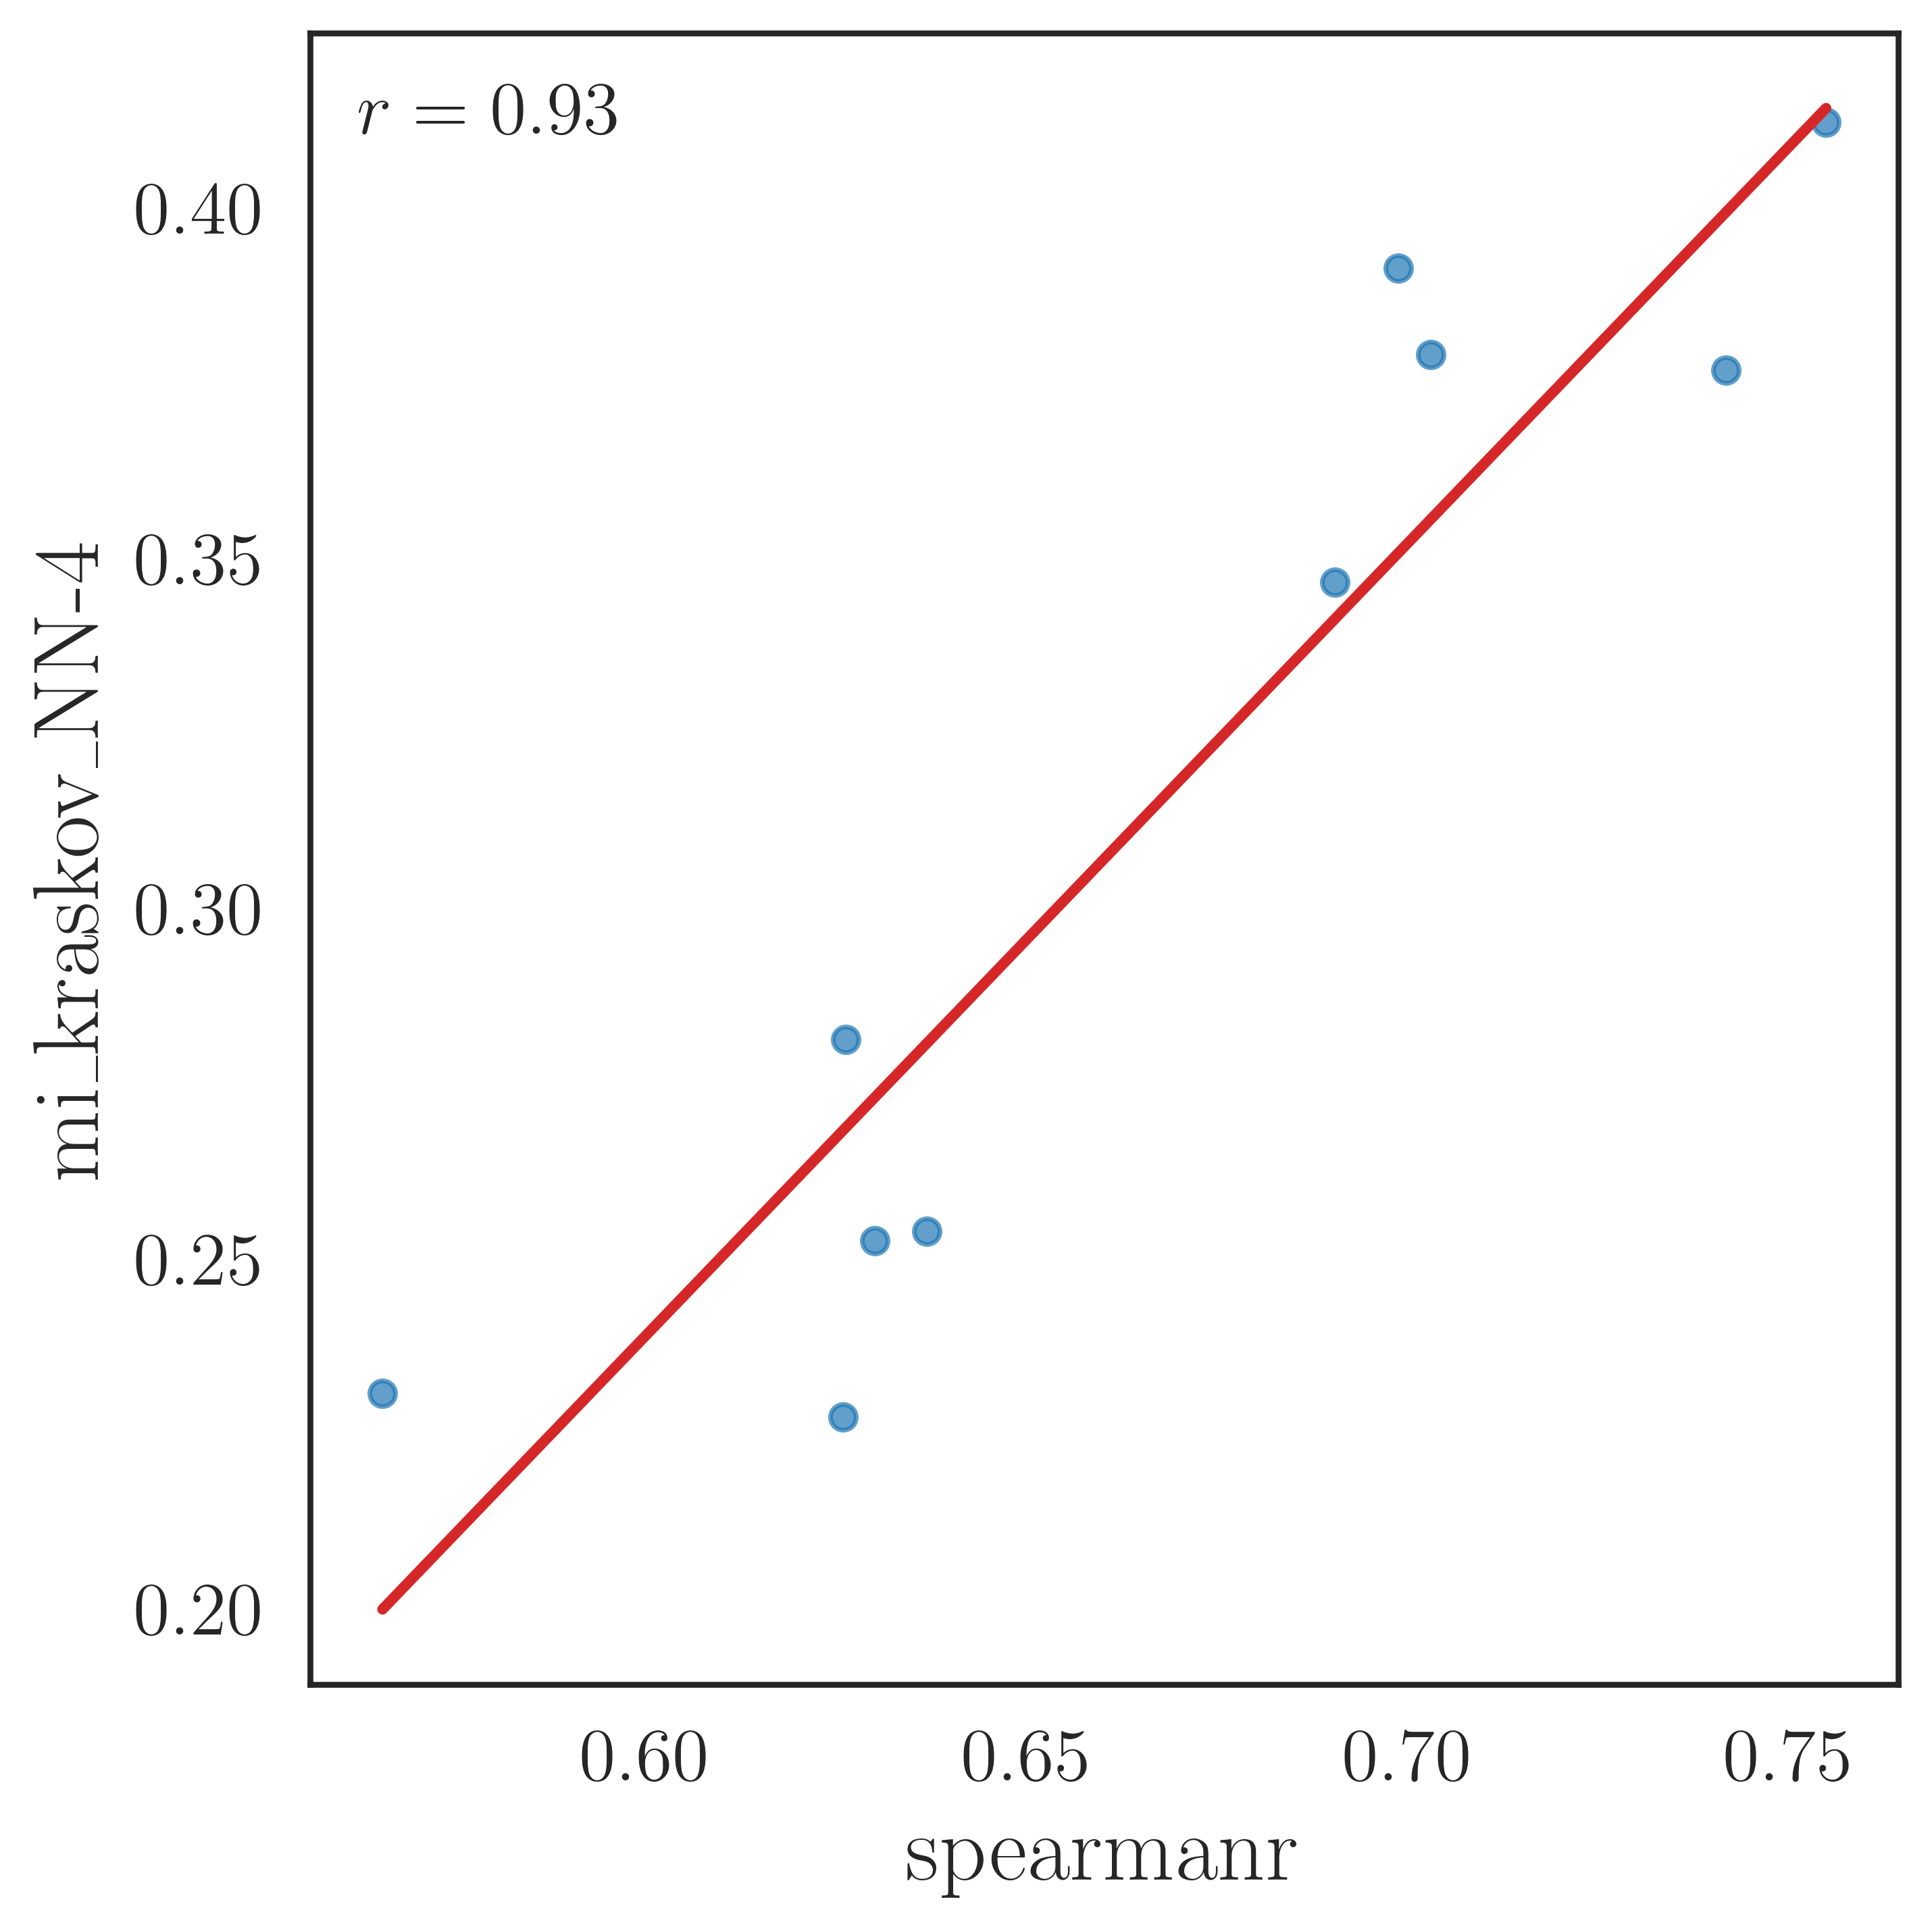

In [22]:
# ---- tweakable ----
spi_x = "spearmanr"
spi_y = "mi_kraskov_NN-4"
scatter_color = "#1f77b4"
reg_color = "#d62728"
scatter_s = 30
scatter_alpha = 0.7
figsize = (6, 6)

with np.load(ARCHIVE) as npz:
    A = np.asarray(npz[spi_x], float)
    B = np.asarray(npz[spi_y], float)
A = 0.5 * (A + A.T)
B = 0.5 * (B + B.T)
mask = np.triu(np.ones(A.shape, bool), k=1)
x_vals = A[mask]; y_vals = B[mask]
finite = np.isfinite(x_vals) & np.isfinite(y_vals)
x_vals = x_vals[finite]; y_vals = y_vals[finite]

r = float(np.corrcoef(x_vals, y_vals)[0, 1])

fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
ax.scatter(x_vals, y_vals, s=scatter_s, alpha=scatter_alpha, color=scatter_color)
sns.regplot(x=x_vals, y=y_vals, ax=ax, scatter=False, color=reg_color, ci=None)
xl = spi_x.replace("_", r"\_") if use_latex else spi_x
yl = spi_y.replace("_", r"\_") if use_latex else spi_y
ax.set_xlabel(xl); ax.set_ylabel(yl)
ax.text(
    0.03, 0.97,
    f"$r = {r:.2f}$",
    transform=ax.transAxes, ha="left", va="top",
)
fig.tight_layout()
fig.savefig(output_dir / f"spi_space_{spi_x}_vs_{spi_y}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
plt.show()